#Customer Segmentation and Churn Prediction

**Customer Segmentation - Understand the different types of customers**

**Churn Prediction - Predict the behaviour of customers**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("Telco_customer_churn.xlsx")

**Exploratory Data Analysis(EDA)**

In [3]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


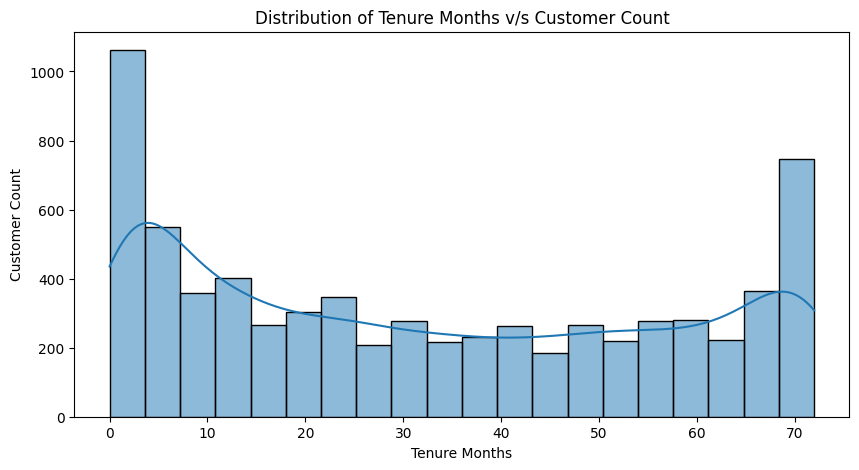

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tenure Months'],bins=20,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months v/s Customer Count')
plt.show()

In [9]:
df['Tenure Months'].max()
df['Tenure Months'].min()

0

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

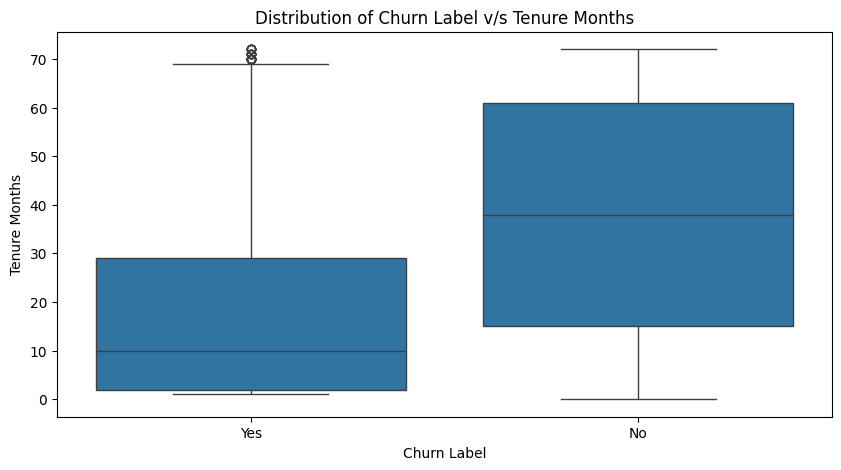

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn Label',y='Tenure Months',data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Distribution of Churn Label v/s Tenure Months')
plt.show()

In [12]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [13]:
df[df['Churn Label']=='Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


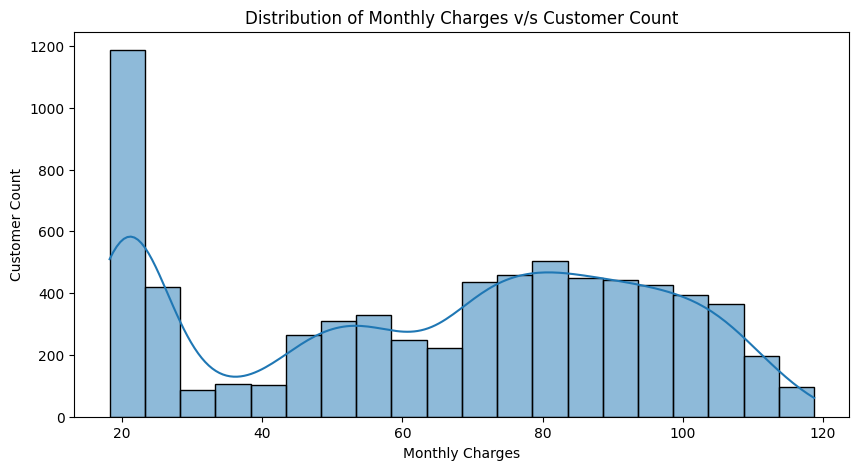

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['Monthly Charges'],bins=20,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Monthly Charges v/s Customer Count')
plt.show()

In [15]:
df['Monthly Charges'].max()

118.75

In [16]:
df['Monthly Charges'].min()

18.25

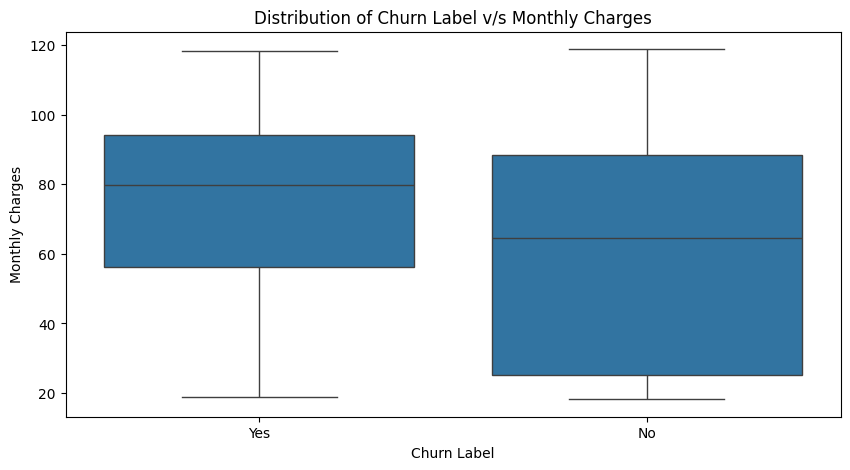

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn Label',y='Monthly Charges',data=df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Distribution of Churn Label v/s Monthly Charges')
plt.show()

In [18]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.50,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [19]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.50,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [20]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [21]:
df['Monthly Charges'].quantile([0.25,0.50,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [22]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

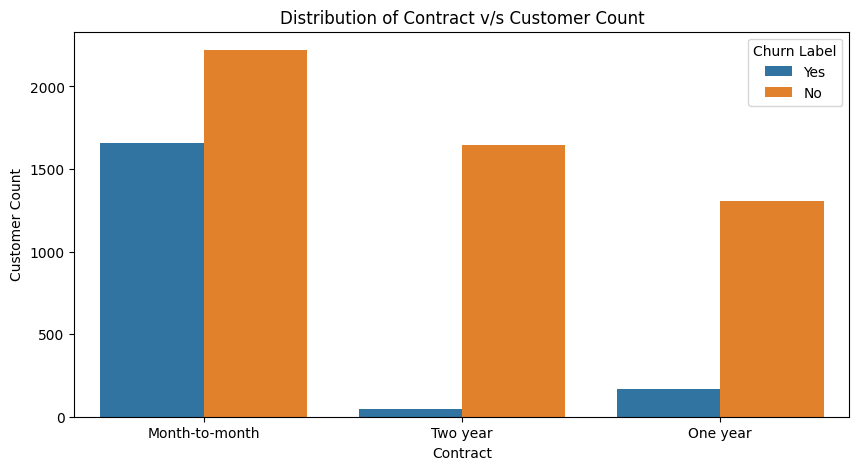

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='Contract', hue='Churn Label',data=df)
plt.xlabel('Contract')
plt.ylabel('Customer Count')
plt.title('Distribution of Contract v/s Customer Count')
plt.show()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [26]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

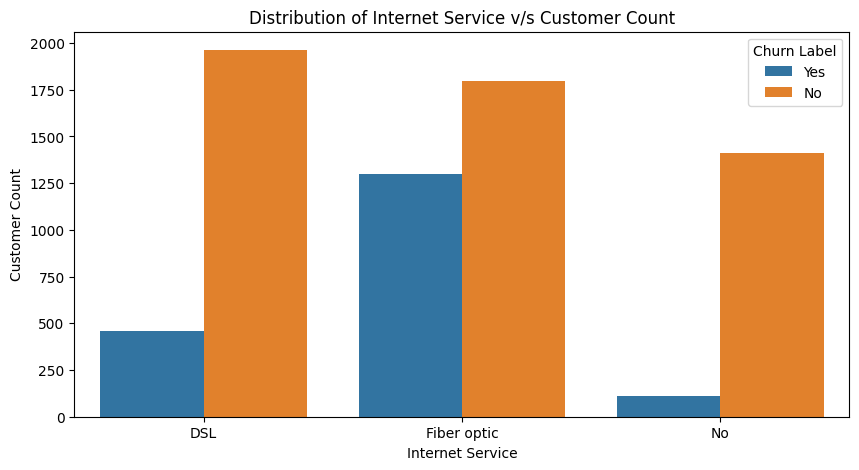

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(x='Internet Service', hue='Churn Label',data=df)
plt.xlabel('Internet Service')
plt.ylabel('Customer Count')
plt.title('Distribution of Internet Service v/s Customer Count')
plt.show()

In [28]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

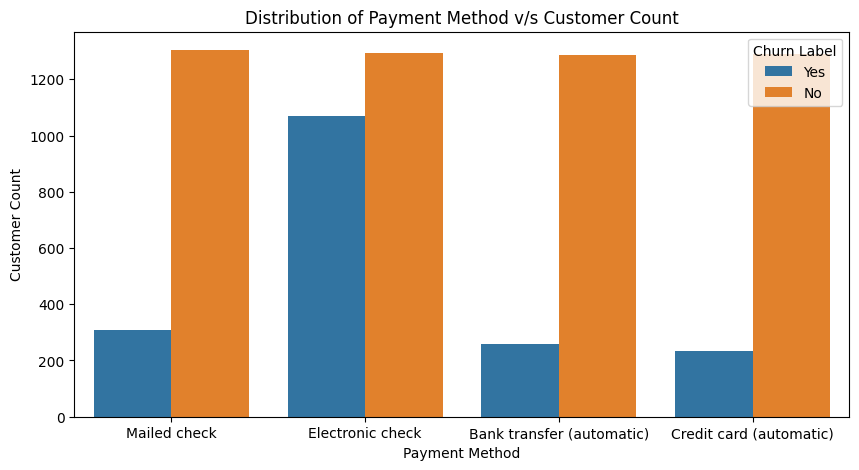

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method', hue='Churn Label',data=df)
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.title('Distribution of Payment Method v/s Customer Count')
plt.show()

In [32]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

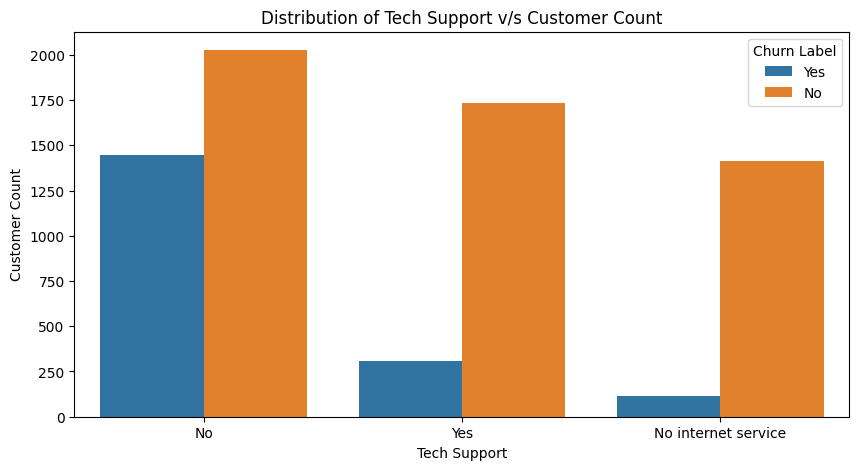

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support', hue='Churn Label',data=df)
plt.xlabel('Tech Support')
plt.ylabel('Customer Count')
plt.title('Distribution of Tech Support v/s Customer Count')
plt.show()

In [36]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()

In [37]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [39]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','CLTV']
correlation_matrix=df[numerical_cols].corr()

In [40]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,CLTV
Tenure Months,1.000000,0.247900,-0.352229,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.098693
Churn Value,-0.352229,0.193356,1.000000,-0.127463
CLTV,0.396406,0.098693,-0.127463,1.000000


In [41]:
contract_churn=pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [43]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [44]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [45]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [46]:
df['Total Charges'].dtype

dtype('float64')

In [47]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [48]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [49]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [50]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [51]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [53]:
drop_columns=['CustomerID', 'Count', 'Country', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']

In [54]:
df=df.drop(columns=drop_columns)

In [55]:
df.shape

(7043, 21)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [57]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [58]:
df['City'].unique()
df['City'].value_counts()

,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [59]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [60]:
df_encoded.shape

(7043, 1159)

In [61]:
df=df.drop(columns=['City'])

In [62]:
df.shape

(7043, 20)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [64]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [65]:
df_encoded.shape

(7043, 31)

In [66]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [70]:
X=df_encoded.drop('Churn Value', axis=1)
Y=df_encoded['Churn Value']

In [71]:
X.shape
Y.shape

(7043,)

In [74]:
X

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,False,False,False,True,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,False,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,False,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,True,False,False,True,True,False,True,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,False,False,False,False,True,False,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,True,False,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,False,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,False,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [75]:
Y

,Churn Value
0,1
1,1
2,1
3,1
4,1
...,...
7038,0
7039,0
7040,0
7041,0


**Machine Learning Implementation**

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [78]:
X_train.shape

(5634, 30)

In [79]:
Y_train.shape

(5634,)

In [80]:
X_test.shape

(1409, 30)

In [81]:
Y_test.shape

(1409,)

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [83]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [84]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [85]:
Y_pred=rf_model.predict(X_test)

In [86]:
Y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [87]:
Y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [88]:
from sklearn.metrics import accuracy_score

In [89]:
accuracy=accuracy_score(Y_test,Y_pred)
accuracy

0.7856635911994322

In [90]:
from sklearn.metrics import confusion_matrix

In [91]:
cm=confusion_matrix(Y_test,Y_pred)
cm

array([[902, 107],
       [195, 205]])

In [96]:
from sklearn.metrics import classification_report

In [100]:
cr=classification_report(Y_test,Y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 1 - Handle Class Imbalance**

In [101]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
Y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test,Y_pred_balanced)
accuracy_balanced

0.7920511000709723

In [102]:
cm_balanced=confusion_matrix(Y_test,Y_pred_balanced)
cm_balanced

array([[907, 102],
       [191, 209]])

In [104]:
print(classification_report(Y_test,Y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 2 - Hyperparamteter Tuning**

In [107]:
rf_tuned=RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced',max_depth=10)
rf_tuned.fit(X_train,Y_train)
Y_pred_tuned=rf_tuned.predict(X_test)
accuracy_tuned=accuracy_score(Y_test,Y_pred_tuned)
accuracy_tuned

0.7828246983676366

In [108]:
cm_tuned=confusion_matrix(Y_test,Y_pred_tuned)
cm_tuned

array([[804, 205],
       [101, 299]])

In [110]:
print(classification_report(Y_test,Y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [228]:
rf_tuned1= RandomForestClassifier(n_estimators=300, max_depth=15,random_state=42, class_weight='balanced') #increased max_depth
rf_tuned1.fit(X_train,Y_train)
Y_pred_tuned1=rf_tuned1.predict(X_test)
accuracy_tuned1=accuracy_score(Y_test,Y_pred_tuned1)
accuracy_tuned1

0.8062455642299503

In [229]:
cm_tuned1=confusion_matrix(Y_test,Y_pred_tuned1)
cm_tuned1

array([[880, 129],
       [144, 256]])

In [230]:
print(classification_report(Y_test,Y_pred_tuned1))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1009
           1       0.66      0.64      0.65       400

    accuracy                           0.81      1409
   macro avg       0.76      0.76      0.76      1409
weighted avg       0.80      0.81      0.81      1409



In [111]:
rf_tuned2=RandomForestClassifier(n_estimators=400,random_state=42,class_weight='balanced',max_depth=10)
rf_tuned2.fit(X_train,Y_train)
Y_pred_tuned2=rf_tuned2.predict(X_test)
accuracy_tuned2=accuracy_score(Y_test,Y_pred_tuned2)
accuracy_tuned2

0.7828246983676366

In [112]:
cm_tuned2=confusion_matrix(Y_test,Y_pred_tuned2)
cm_tuned2

array([[804, 205],
       [101, 299]])

In [113]:
print(classification_report(Y_test,Y_pred_tuned2))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [114]:
rf_tuned3=RandomForestClassifier(n_estimators=400,random_state=42,class_weight='balanced',max_depth=15)
rf_tuned3.fit(X_train,Y_train)
Y_pred_tuned3=rf_tuned3.predict(X_test)
accuracy_tuned3=accuracy_score(Y_test,Y_pred_tuned3)
accuracy_tuned3

0.8034066713981547

In [115]:
cm_tunned3=confusion_matrix(Y_test,Y_pred_tuned3)
cm_tunned3

array([[877, 132],
       [145, 255]])

In [116]:
print(classification_report(Y_test,Y_pred_tuned3))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1009
           1       0.66      0.64      0.65       400

    accuracy                           0.80      1409
   macro avg       0.76      0.75      0.76      1409
weighted avg       0.80      0.80      0.80      1409



**Approach 3 - Feature Importance Analysis**

In [124]:
import pandas as pd
feature_importances=pd.DataFrame({'Features':X.columns,'Importance':rf_tuned.feature_importances_})
feature_importance=feature_importances.sort_values(by='Importance',ascending=False)
print(feature_importances)

                                  Features  Importance
0                            Tenure Months    0.179069
1                          Monthly Charges    0.093681
2                            Total Charges    0.136460
3                              Gender_Male    0.012586
4                       Senior Citizen_Yes    0.010257
5                              Partner_Yes    0.015846
6                           Dependents_Yes    0.068517
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725
9                       Multiple Lines_Yes    0.011690
10            Internet Service_Fiber optic    0.060228
11                     Internet Service_No    0.012673
12     Online Security_No internet service    0.014973
13                     Online Security_Yes    0.029356
14       Online Backup_No internet service    0.010298
15                       Online Backup_Yes    0.012213
16   Device Protection_No internet service    0.012985
17        

In [125]:
print(feature_importance.tail(15))

                                  Features  Importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


In [126]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [127]:
X_train_sel,X_test_sel,Y_train_sel,Y_test_sel=train_test_split(X_selected,Y,test_size=0.2,random_state=42)

In [128]:
rf_selected=RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced',max_depth=10)
rf_selected.fit(X_train_sel,Y_train_sel)
Y_pred_sel=rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel,Y_pred_sel))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



**Approach 4 - Combination of Trees and Depth**

In [130]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        rf_model=RandomForestClassifier(n_estimators=n_estimators,random_state=42,class_weight='balanced',max_depth=max_depth)
        rf_model.fit(X_train,Y_train)
        Y_pred=rf_model.predict(X_test)

In [134]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [135]:
from sklearn.ensemble import RandomForestClassifier

In [138]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_estimators in n_estimators_list:
    for max_depth in max_depth_list:
        rf_model=RandomForestClassifier(n_estimators=n_estimators,random_state=42,class_weight='balanced',max_depth=max_depth)
        rf_model.fit(X_train,Y_train)
        Y_pred=rf_model.predict(X_test)
        accuracy=accuracy_score(Y_test,Y_pred)
        recall=recall_score(Y_test,Y_pred)
        precision=precision_score(Y_test,Y_pred)
        f1=f1_score(Y_test,Y_pred)
        results.append({'n_estimators':n_estimators,'max_depth':max_depth,'accuracy':accuracy,'recall':recall,'precision':precision,'f1':f1})
results_df=pd.DataFrame(results)
results_df=results_df.sort_values(by=['recall','accuracy'],ascending=False)
print(results_df.head(20))

    n_estimators  max_depth  accuracy  recall  precision        f1
0            100          5  0.745919  0.8200   0.534202  0.646943
8            300          5  0.743790  0.8200   0.531605  0.645034
12           400          5  0.743790  0.8125   0.531915  0.642928
4            200          5  0.742370  0.8100   0.530278  0.640950
16           500          5  0.740951  0.8050   0.528736  0.638256
1            100         10  0.775727  0.7525   0.581081  0.655773
9            300         10  0.782825  0.7475   0.593254  0.661504
13           400         10  0.782825  0.7475   0.593254  0.661504
17           500         10  0.781405  0.7475   0.590909  0.660044
5            200         10  0.782115  0.7450   0.592445  0.660022
10           300         15  0.806246  0.6400   0.664935  0.652229
14           400         15  0.803407  0.6375   0.658915  0.648030
18           500         15  0.801987  0.6375   0.655527  0.646388
6            200         15  0.804826  0.6350   0.663185  0.64

In [139]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,random_state=42,class_weight='balanced',max_depth=10)

In [144]:
cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')
cv_accuracy

array([0.76721079, 0.79772889, 0.76224273, 0.78551136, 0.78409091])

In [145]:
cv_accuracy.mean()

np.float64(0.7793569343183432)

In [146]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')
cv_recall

array([0.70855615, 0.76470588, 0.74064171, 0.74331551, 0.71045576])

In [147]:
cv_recall.mean()

np.float64(0.7335350030823931)

**Approach 5 - Optional**

In [151]:
from sklearn.metrics import roc_auc_score,roc_curve
import matplotlib.pyplot as plt

In [152]:
Y_prob=rf_tuned.predict_proba(X)

In [153]:
Y_prob1=rf_tuned.predict_proba(X_test)

In [167]:
churn_probability=Y_prob[:,1]

In [162]:
churn_prob=Y_prob1[:,1]

In [164]:
fpr,tpr,thresholds=roc_curve(Y_test,churn_prob)
auc_score=roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.857104806739346


**Customer Segmentation**

In [208]:
segmentation_data = pd.DataFrame({'Tenure Months': X['Tenure Months'],'Monthly Charges': X['Monthly Charges'],'Total Charge': X['Total Charges'],'Churn Probability': churn_probability})
segmentation_data

,Tenure Months,Monthly Charges,Total Charge,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


**Implementation of K means**

In [209]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [210]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


In [211]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

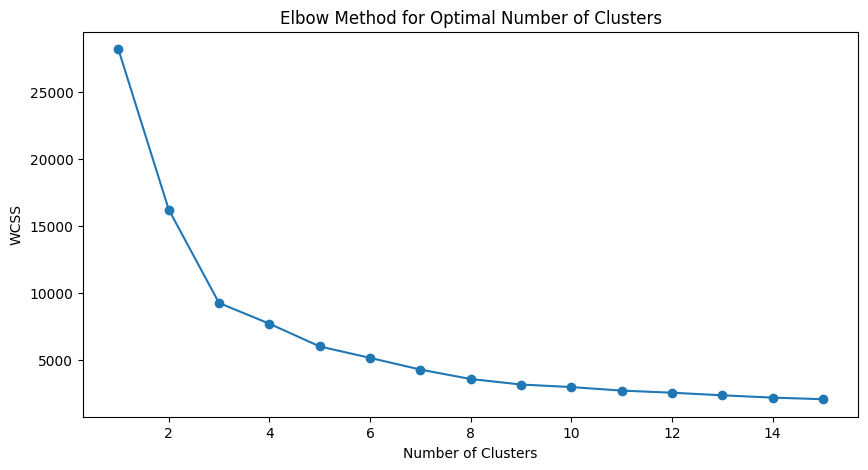

In [213]:
plt.figure(figsize=(10,5))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

In [214]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [215]:
clusters=kmeans.fit_predict(scaled_data)

In [216]:
segmentation_data['Cluster']=clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charge,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [218]:
cluster_summary=segmentation_data.groupby('Cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charge,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [219]:
cluster_names={0:'Budget Loyal Customer',1:'High Risk New Customer',2:'Loyal Premium Cutomer'}

In [220]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charge,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High Risk New Customer
1,2,70.70,151.65,0.796013,1,High Risk New Customer
2,8,99.65,820.50,0.805827,1,High Risk New Customer
3,28,104.80,3046.05,0.563031,1,High Risk New Customer
4,49,103.70,5036.30,0.517474,2,Loyal Premium Cutomer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal Customer
7039,24,84.80,1990.50,0.082095,0,Budget Loyal Customer
7040,72,103.20,7362.90,0.049001,2,Loyal Premium Cutomer
7041,11,29.60,346.45,0.302367,0,Budget Loyal Customer


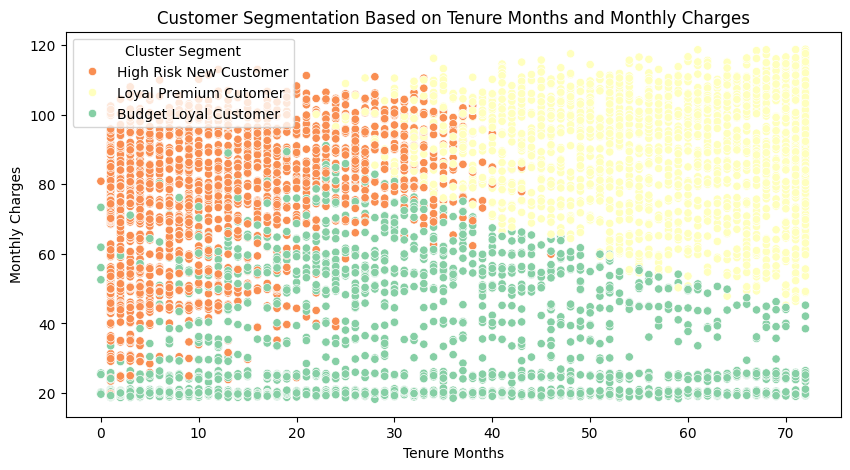

In [225]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months',y='Monthly Charges',hue='Cluster Segment',data=segmentation_data,palette='Spectral')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.title('Customer Segmentation Based on Tenure Months and Monthly Charges')
plt.show()

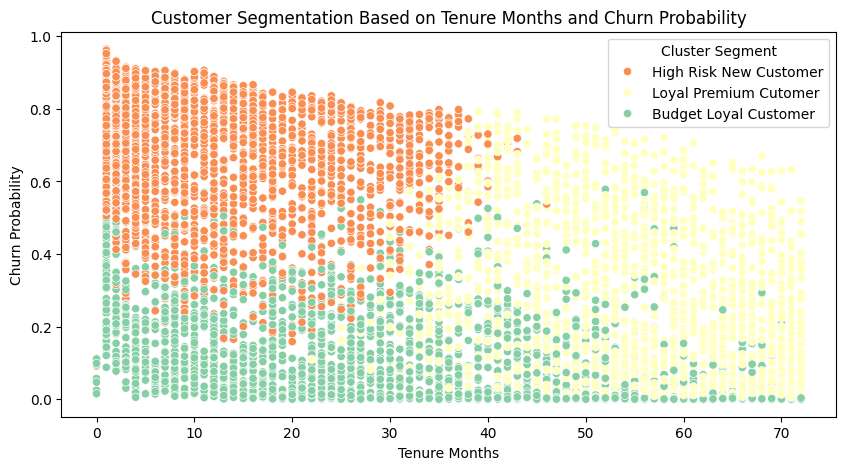

In [224]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.title('Customer Segmentation Based on Tenure Months and Churn Probability')
plt.show()

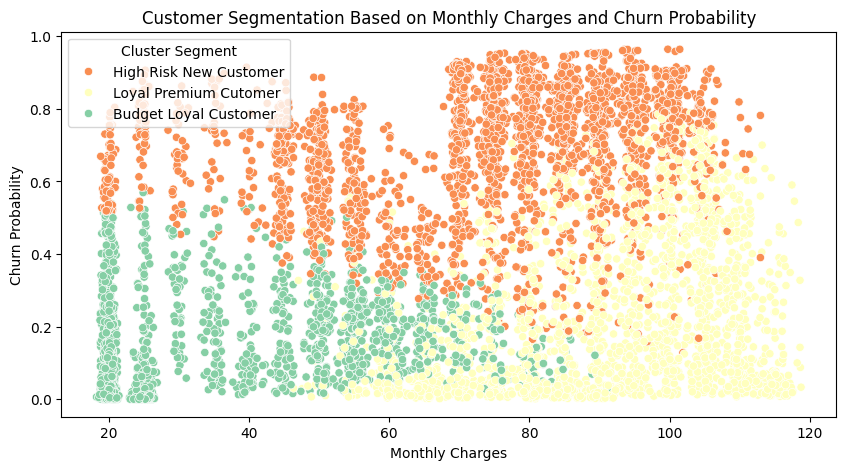

In [226]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Probability')
plt.title('Customer Segmentation Based on Monthly Charges and Churn Probability')
plt.show()

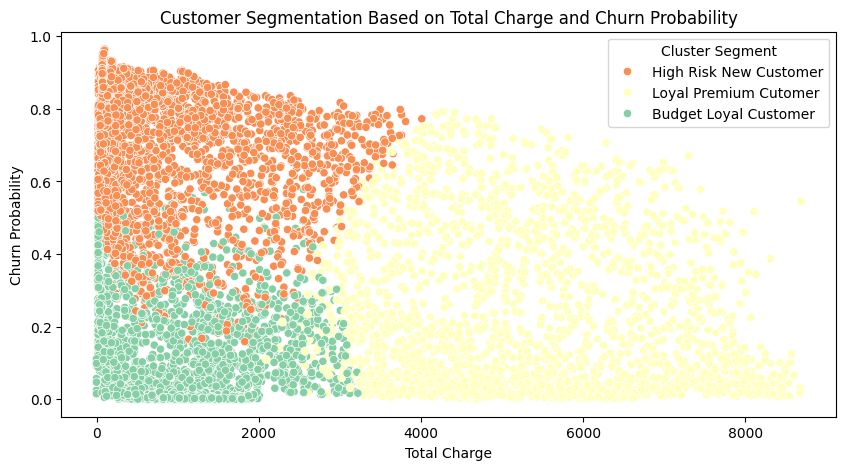

In [227]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Total Charge',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')
plt.xlabel('Total Charge')
plt.ylabel('Churn Probability')
plt.title('Customer Segmentation Based on Total Charge and Churn Probability')
plt.show()